#### Compute Cls ####

In [2]:
import numpy as np, local, os, tqdm, sys
from scipy.integrate import solve_ivp
from matplotlib.pyplot import *

In [9]:
dir_pyrefclass = '/global/homes/t/toshiyan/Work/Ongoing/rotation/code/pyrefCLASS' # directory of pyrefCLASS
sys.path.append(dir_pyrefclass)
import pyrefCLASS as rot

In [92]:
import importlib
importlib.reload(rot)

<module 'pyrefCLASS' from '/global/homes/t/toshiyan/Work/Ongoing/rotation/code/pyrefCLASS/pyrefCLASS.py'>

In [126]:
outroot = '../data_local/2026-03-26_inject/' # output directory
Neta  = 10000 # number of time steps for output phi(eta)
mass  = np.array([-30.5]) # log10 m_phi
beta0 = 0.34*np.pi/180. # beta at recombination [rad]
tau   = np.array([0.095]) # CMB optical depth
n, tf = 1, 100 # parameters for ALP potential
#xi    = np.array([1e-4,5e-4,1e-3,2e-3]) # energy transfer fraction
xi    = np.array([1.1e-2]) # energy transfer fraction
z_start = 60 # start of energy transfer
z_end = 50 # end of energy transfer
eps = 1e-8 # numerical parameter for 1/phi'
ow = True

In [127]:
#for t in tqdm.tqdm(tau):
t = tau[0]
for x in tqdm.tqdm(xi):
    for logm in tqdm.tqdm(mass):
        # define filename tag
        base_tag = 'inject_tau' + str(t) + '_logm' + str(logm) + '_xi' + str(x) + '_N' + str(Neta) 
        # output filename for cls
        ofile = outroot + base_tag + '_cl.dat'
        if os.path.exists(ofile) and not ow:
            print(ofile+' exist', end='', flush=True)
            continue
        else:
            # solve phi as a function of eta
            rot.export_axion_dynamics_a(Neta, local.EoM_phi, [logm,tf,n,x,eps,z_start,z_end], rot.dir_phi+base_tag )
            # create inifile for birefCLASS
            rot.create_inifile(
                beta0, base_tag, Neta, base_tag, default_ini_file='biref_default_inject.ini', tau_reio=t, 
                outroot=outroot, phi_dynamics_dir=rot.dir_phi
            )
            # run birefCLASS to compute cls
            os.system(
                rot.path_to_birefCLASS+'/class '+rot.dir_ini+base_tag+'.ini '+rot.path_to_birefCLASS+'/cl_ref_biref.pre > test.txt'
            )
            # delete non-necessary files
            for tag in ['cls.dat','clt.dat','parameters.ini','primordial_Pk.dat','thermodynamics.dat','unused_parameters','background.dat']:
                os.system('rm -rf '+outroot+base_tag+'_'+tag)
            os.system('rm -rf '+rot.dir_ini+base_tag+'.ini')

  0%|          | 0/1 [00:00<?, ?it/s]
%|          | 0/1 [00:00<?, ?it/s]
100%|██████████| 1/1 [00:53<00:00, 53.19s/it]


In [128]:
cls = np.loadtxt(ofile,unpack=True)

In [129]:
lcl0 = np.loadtxt('../data_local/2025-01-09_ALP/alpha0.3deg_p0_1e-33_N10000+cl.dat',unpack=True,max_rows=3000)

/tmp/ipykernel_1158553/3145512480.py:1: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=3000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  lcl0 = np.loadtxt('../data_local/2025-01-09_ALP/alpha0.3deg_p0_1e-33_N10000+cl.dat',unpack=True,max_rows=3000)


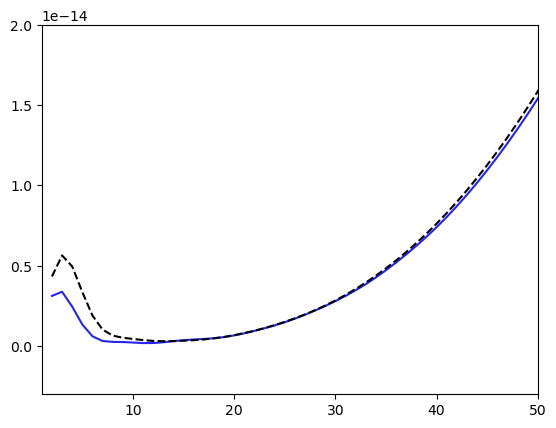

In [130]:
xlim(1,50)
ylim(-3e-15,2e-14)
plot(cls[0],cls[2])
plot(lcl0[0],lcl0[2],color='k',ls='--')

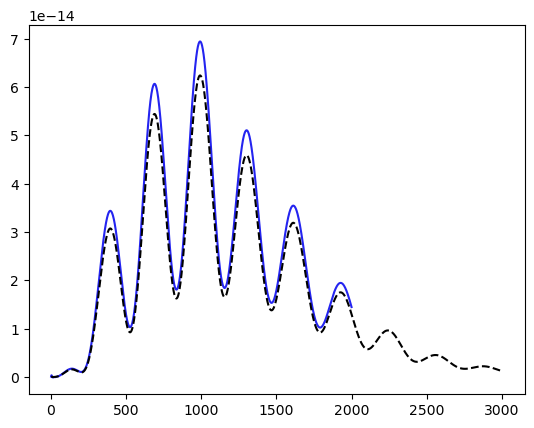

In [131]:
plot(cls[0],cls[5])
plot(lcl0[0],lcl0[5],color='k',ls='--')